<a href="https://colab.research.google.com/github/triastrale/stemming/blob/snowball_stemmer/StemmingInggris_Kel7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk

In [ ]:
import pandas as pd
from nltk.stem import SnowballStemmer
import nltk
from nltk.corpus import stopwords

# Download dulu data nltk (kalau baru pertama kali pakai)
nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
# Baca file CSV
df = pd.read_csv('/content/Dataset_English - Sheet1.csv')  # Ganti nama file sesuai file kamu


In [ ]:
# Bikin stemmer untuk English
stemmer = SnowballStemmer("english")

# Fungsi stemming untuk satu kalimat
def stemming_kalimat(kalimat):
    if pd.isnull(kalimat):
        return ""
    words = kalimat.split()
    stemmed_words = [stemmer.stem(word) for word in words if word.lower() not in stop_words]
    return ' '.join(stemmed_words)


In [ ]:
# Terapkan stemming ke kolom 'judul' dan 'isi'
df['judul_stemmed'] = df['Judul'].apply(stemming_kalimat)
df['isi_stemmed'] = df['Isi'].apply(stemming_kalimat)

# Lihat hasilnya
df[['Judul', 'judul_stemmed', 'Isi', 'isi_stemmed']].head()


,Judul,judul_stemmed,Isi,isi_stemmed
0,7 Drugs That Changed the World,7 drug chang world,"People have swallowed elixirs, inhaled vapors,...","peopl swallow elixirs, inhal vapors, appli oin..."
1,A 'Black Snape' in the new Harry Potter seems ...,black snape new harri potter seem design caus ...,Ignore the fuss: Paapa Essiedu is a brilliant ...,ignor fuss: paapa essiedu brilliant actor brin...
2,Alexander Fleming,alexand fleme,In 1928 Alexander Fleming (1881–1955) discover...,1928 alexand fleme (1881–1955) discov penicill...
3,An anonymous 4chan post could help solve a 25-...,anonym 4chan post could help solv 25-year-old ...,A 4chan poster may have solved part of a very ...,4chan poster may solv part tricki math problem...
4,Are breakfast cereals really good for us?,breakfast cereal realli good us?,Fortified breakfast cereals can be a useful so...,"fortifi breakfast cereal use sourc fibre, vita..."


In [ ]:
# Simpan hasil stemming ke CSV baru
df.to_csv('hasil_stemming.csv', index=False, encoding='utf-8-sig')

print("Sukses stemming! Hasil disimpan ke hasil_stemming.csv")


Sukses stemming! Hasil disimpan ke hasil_stemming.csv


In [ ]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Fungsi untuk menghitung Unigram Index (UI)
def unigram_index(text_column):
    all_words = ' '.join(text_column).split()  # Gabung semua teks jadi satu string
    return dict(Counter(all_words))  # Hitung frekuensi tiap kata

In [ ]:
# Fungsi untuk menghitung Occurrence Index (OI)
def occurrence_index(text_column):
    all_words = ' '.join(text_column).split()  # Gabung semua teks jadi satu string
    return dict(Counter(all_words))  # Hitung kemunculan tiap kata

In [ ]:
# Fungsi untuk menghitung Mean Word Count (MWC)
def mean_word_count(text_column):
    word_counts = text_column.apply(lambda x: len(str(x).split()))  # Hitung jumlah kata per kalimat
    return word_counts.mean()  # Rata-rata jumlah kata per kalimat

In [ ]:
df_stemmed = pd.read_csv('/content/hasil_stemming.csv')

In [ ]:
# 1. Unigram Index (UI) untuk 'judul_stemmed' dan 'isi_stemmed'
ui_judul = unigram_index(df_stemmed['judul_stemmed'])
ui_isi = unigram_index(df['isi_stemmed'])
# Menampilkan hasil UI, OI, dan MWC
print("Unigram Index (UI) untuk Judul:")
print(ui_judul)

print("\nUnigram Index (UI) untuk Isi:")
print(ui_isi)

Unigram Index (UI) untuk Judul:
{'7': 1, 'drug': 1, 'chang': 2, 'world': 2, 'black': 1, 'snape': 1, 'new': 2, 'harri': 1, 'potter': 1, 'seem': 1, 'design': 1, 'caus': 1, 'controversi': 1, '-': 2, 'could': 2, 'work': 1, 'alexand': 1, 'fleme': 1, 'anonym': 1, '4chan': 1, 'post': 1, 'help': 2, 'solv': 1, '25-year-old': 1, 'math': 1, 'mysteri': 1, 'breakfast': 1, 'cereal': 1, 'realli': 1, 'good': 1, 'us?': 1, 'presid': 2, 'revok': 2, 'univers': 1, 'tax-exempt': 1, 'status?': 1, 'everi': 1, 'doctor': 1, 'face': 2, 'dilemma': 1, 'deport': 1, 'salvadoran': 1, 'man': 1, 'becom': 1, 'hing': 1, 'point': 1, 'us': 2, 'histori': 1, 'trump': 4, 'coloss': 1, 'failur': 1, 'stun': 1, 'success': 1, 'israel': 1, 'must': 1, 'stop': 1, 'apolog': 1, 'exist': 2, 'opinion': 1, 'firm': 1, 'say': 1, 'meta': 1, 'recov': 1, 'hack': 1, 'account': 1, 'global': 1, 'growth': 1, 'forecast': 1, 'slash': 1, 'imf': 1, 'tariff': 2, 'impact': 1, 'canadian': 1, 'dane': 1, 'boycot': 1, 'american': 1, 'product': 1, 'dream': 1

In [ ]:
# 2. Occurrence Index (OI) untuk 'judul_stemmed' dan 'isi_stemmed'
from collections import Counter

# Fungsi untuk menghitung Occurrence Index (OI)
def occurrence_index(text_column):
    all_words = ' '.join(text_column).split()  # Gabung semua teks jadi satu string
    return dict(Counter(all_words))  # Hitung kemunculan tiap kata

oi_judul = occurrence_index(df_stemmed['judul_stemmed'])
oi_isi = occurrence_index(df_stemmed['isi_stemmed'])
print("\nOccurrence Index (OI) untuk Judul:")
print(oi_judul)

print("\nOccurrence Index (OI) untuk Isi:")
print(oi_isi)


Occurrence Index (OI) untuk Judul:
{'7': 1, 'drug': 1, 'chang': 2, 'world': 2, 'black': 1, 'snape': 1, 'new': 2, 'harri': 1, 'potter': 1, 'seem': 1, 'design': 1, 'caus': 1, 'controversi': 1, '-': 2, 'could': 2, 'work': 1, 'alexand': 1, 'fleme': 1, 'anonym': 1, '4chan': 1, 'post': 1, 'help': 2, 'solv': 1, '25-year-old': 1, 'math': 1, 'mysteri': 1, 'breakfast': 1, 'cereal': 1, 'realli': 1, 'good': 1, 'us?': 1, 'presid': 2, 'revok': 2, 'univers': 1, 'tax-exempt': 1, 'status?': 1, 'everi': 1, 'doctor': 1, 'face': 2, 'dilemma': 1, 'deport': 1, 'salvadoran': 1, 'man': 1, 'becom': 1, 'hing': 1, 'point': 1, 'us': 2, 'histori': 1, 'trump': 4, 'coloss': 1, 'failur': 1, 'stun': 1, 'success': 1, 'israel': 1, 'must': 1, 'stop': 1, 'apolog': 1, 'exist': 2, 'opinion': 1, 'firm': 1, 'say': 1, 'meta': 1, 'recov': 1, 'hack': 1, 'account': 1, 'global': 1, 'growth': 1, 'forecast': 1, 'slash': 1, 'imf': 1, 'tariff': 2, 'impact': 1, 'canadian': 1, 'dane': 1, 'boycot': 1, 'american': 1, 'product': 1, 'dream

In [ ]:
# 3. Mean Word Count (MWC) untuk 'judul_stemmed' dan 'isi_stemmed'
mwc_judul = mean_word_count(df_stemmed['judul_stemmed'])
mwc_isi = mean_word_count(df_stemmed['isi_stemmed'])
print(f"\nMean Word Count (MWC) untuk Judul: {mwc_judul}")
print(f"Mean Word Count (MWC) untuk Isi: {mwc_isi}")


Mean Word Count (MWC) untuk Judul: 6.466666666666667
Mean Word Count (MWC) untuk Isi: 629.7333333333333


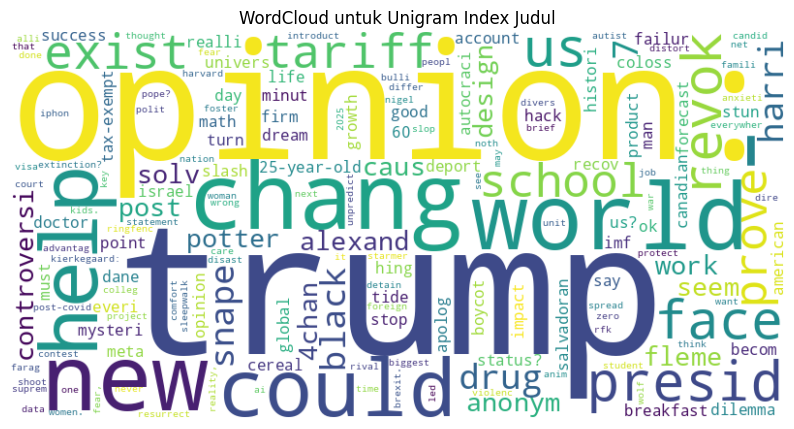

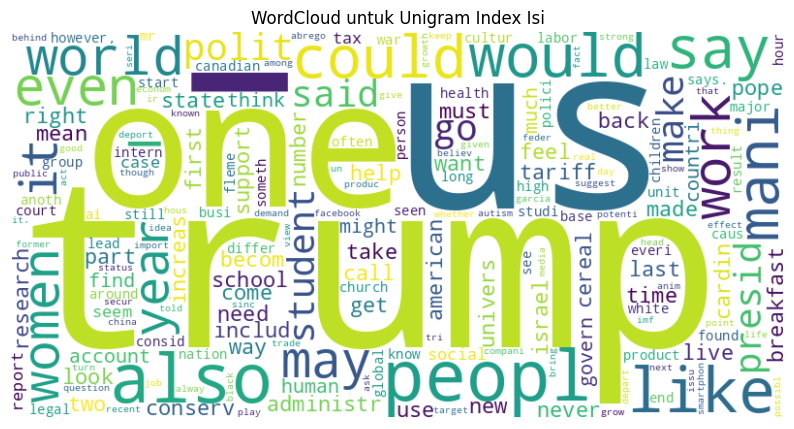

In [ ]:
# Visualisasi WordCloud untuk UI

def plot_wordcloud(word_freq, title):
    wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Visualisasi WordCloud untuk UI Judul dan Isi
plot_wordcloud(ui_judul, 'WordCloud untuk Unigram Index Judul')
plot_wordcloud(ui_isi, 'WordCloud untuk Unigram Index Isi')

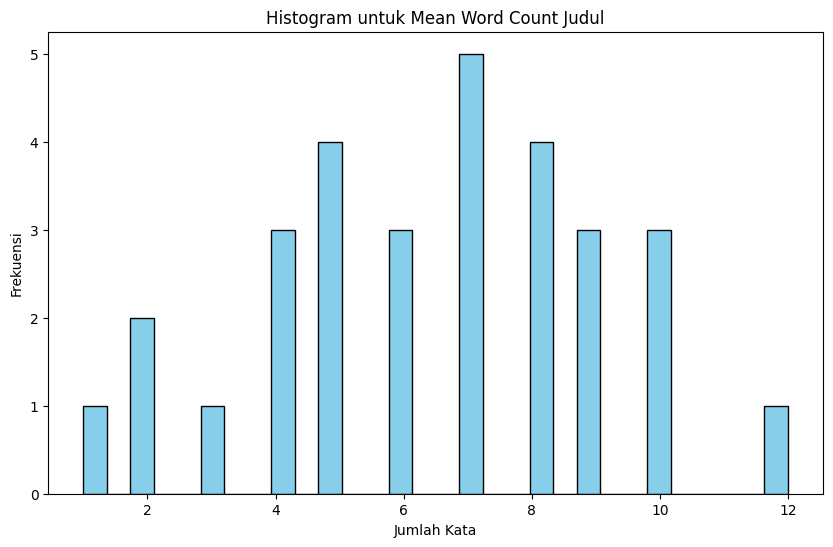

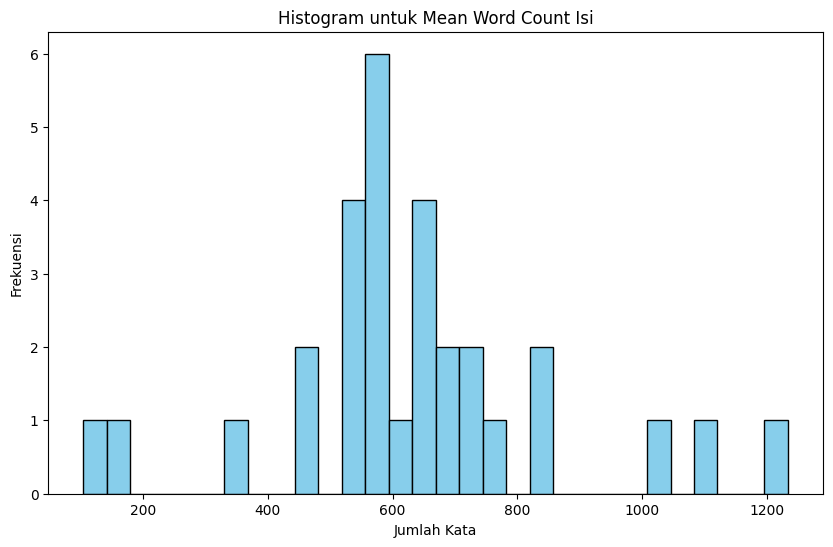

In [ ]:
# Visualisasi Histogram untuk MWC
def plot_histogram(word_count_column, title):
    word_counts = word_count_column.apply(lambda x: len(str(x).split()))
    plt.figure(figsize=(10, 6))
    plt.hist(word_counts, bins=30, color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel('Jumlah Kata')
    plt.ylabel('Frekuensi')
    plt.show()

# Visualisasi Histogram untuk MWC Judul dan Isi
plot_histogram(df_stemmed['judul_stemmed'], 'Histogram untuk Mean Word Count Judul')
plot_histogram(df_stemmed['isi_stemmed'], 'Histogram untuk Mean Word Count Isi')